## <span style="color:blue"> Lezione 10 </span>



In [1]:

import matplotlib.pyplot as plt


import numpy as np

parent_folder="l_10_all_es/OUTPUT/"

### <span style="color:DodgerBlue"> Esercizio 10.1-10.2 </span>



Si è scelta l'opzione 1: 

> Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**: each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.


L'esercizio riprende dall'algoritmo genetico della lezione precedente ed implementa una parallelizzazione di esso su $T$ core. 

Ogni core porta avanti una popolazione, che evolve in modo separato dalle altre. Ogni $S$ generazioni, però, i core si scambiano l'individuo migliore della loro popolazione. L'ordine dello scambio è dettato da una permutazione casuale $P$ di $[1,...,T]$: ogni core riceve dall'individuo alla propria sinistra e manda all'individuo alla propria destra in $P$ (con condizioni periodiche al contorno). La permutazione di $P$ viene effettuata dal solo rank $0$ e poi comunicata agli altri tramite 
```cpp
    MPI_Bcast(communication_order.memptr(), communication_order.n_elem, MPI_LONG_LONG, 0, MPI_COMM_WORLD);
```

dove `communication_order` è l'array di Armadillo (`arma::irowvec`) corrispondente a $P$. 

Lo scambio di individui viene effettuato tramite l'utilizzo di comunicazioni non bloccanti: 

```cpp
        MPI_Isend(send_best_chromosome.memptr(), chromosome_size, MPI_LONG_LONG, receiver, 0, MPI_COMM_WORLD, &send_req);
        MPI_Irecv(receive_best_chromosome.memptr(), chromosome_size, MPI_LONG_LONG, sender, 0, MPI_COMM_WORLD, &rec_req);
```

accompagnate da `MPI_Wait()`. `send_best_chromosome ` e `receive_best_chromosome` sono sempre array `arma::irowvec`. 


Per garantire che ogni core segua una sequenza random diversa dalle altre, il caricamento dal file `Primes` è stato gestito così: 

```cpp
    if (Primes.is_open()){
        for(int i=0; i <= rank; i++){
            Primes >> p1 >> p2 ;
        }
    } else cerr << "PROBLEM: Unable to open Primes" << endl;

```
In questo modo, ogni rank $i$ inizializza il generatore con i numeri della $i$-esima riga di `Primes`, ottenendo sequenze diverse.

Il codice è stato testato con $T=11$ core sulle $R=110$ province italiane, caricate nella cella sottosante, con $M=1500$ individui per generazione, $N=1000$ generazioni, e migrazioni ogni $S=100$ generazioni.

I parametri scelti per l'algoritmo genetico sono: 

- Probabilità di mutazione: $P_m = 0.1$
- Probabilità di crossover: $P_x = 0.8$
- Esponente di selezione: $p = 5.0$
- Frazioni di mutazione:
    - _swap_ $S_w = 0.05$
    - _reverse_ $S_r = 0.5$
    - _permutate_ $S_p= 0.05$ 
    - _shift_ $S_s = 0.4$


In [2]:

cities=np.loadtxt(f"l_10_all_es/INPUT/cap_prov_ita.dat")


Nella cella seguente vengono caricati i risultati.

In [3]:

N_cores=11

cols=range(3,3 + len(cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1



#per ogni core
best_paths=[]#salva il miglior percorso in assoluto
best_lenghts=[]#salva la lunghezza del miglior percorso per ogni generazione
avg_lenghts=[]#salva la lunghezza media della metà migliore della popolazione per ogni generazione


for i in range(N_cores): 

    filename=f"W_MIGR/rank_{i}_pop.csv"
    avg_len,best_len=np.loadtxt(f"{parent_folder}{filename}",usecols=(1,2),unpack=True,skiprows=1)
    best_lenghts.append(best_len)
    avg_lenghts.append(avg_len)

    best_paths.append(np.loadtxt(f"{parent_folder}{filename}",usecols=cols,skiprows=(len(best_lenghts[0]))))#carica solo l'ultimo percorso (il migliore di tutti)

  


gen=np.arange(1,len(best_lenghts[0])+1)



Nella cella sottostante, vengono graficati i risultati.

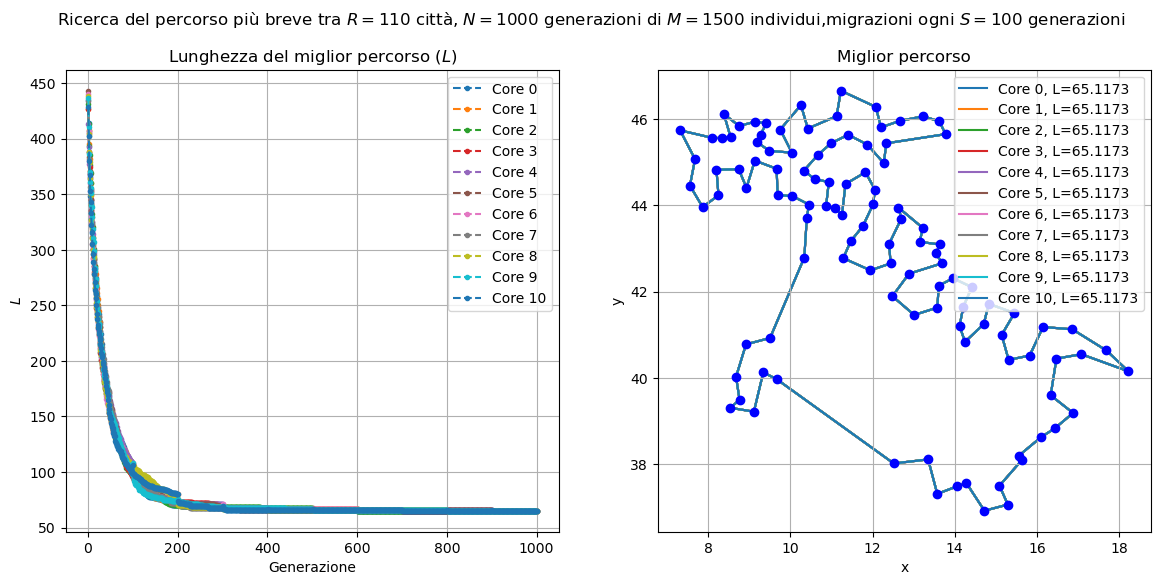

In [4]:
fig,axs=plt.subplots(1,2,figsize=[14,6])
axs[1].scatter(cities[:,0],cities[:,1],color="blue",zorder=2)#città 

for i,best_path in enumerate(best_paths):

    axs[0].plot(gen,best_lenghts[i],"--.",label=f"Core {i}")
    #axs[0].plot(gen,avg_lenghts[i],"--.",label=f"Core {i}, avg")

    
    index=best_path.astype(int)#ordine in cui le città vengono visitate (percorso migliore)
    axs[1].plot(cities[index,0],cities[index,1],zorder=1,label=f"Core {i}, L={best_lenghts[i][-1]:.4f}") #unisce le città nell'ordine in cui vengono visitate




axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()





axs[1].grid()
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].set_title("Miglior percorso")
axs[1].legend()
fig.suptitle(r"Ricerca del percorso più breve tra $R=110$ città, $N=1000$ generazioni di $M=1500$ individui,migrazioni ogni $S=100$ generazioni");


Tutti i core convergono allo stesso percorso, di lunghezza $L=65.1173$.



Si vuole ora valutare l'impatto delle migrazioni sul risultato finale. A questo proposito, si riapplica l'algoritmo con gli stessi parametri, ma senza permettere agli individui di migrare tra i core. 

In [5]:


#per ogni core
NM_best_paths=[]#salva il miglior percorso in assoluto
NM_best_lenghts=[]#salva la lunghezza del miglior percorso per ogni generazione
NM_avg_lenghts=[]#salva la lunghezza media della metà migliore della popolazione per ogni generazione


for i in range(N_cores): 

    filename=f"NO_MIGR/rank_{i}_pop.csv"
    avg_len,best_len=np.loadtxt(f"{parent_folder}{filename}",usecols=(1,2),unpack=True,skiprows=1)
    NM_best_lenghts.append(best_len)
    NM_avg_lenghts.append(avg_len)

    NM_best_paths.append(np.loadtxt(f"{parent_folder}{filename}",usecols=cols,skiprows=(len(NM_best_lenghts[0]))))#carica solo l'ultimo percorso (il migliore di tutti)

  
NM_gen=np.arange(1,len(NM_best_lenghts[0])+1)





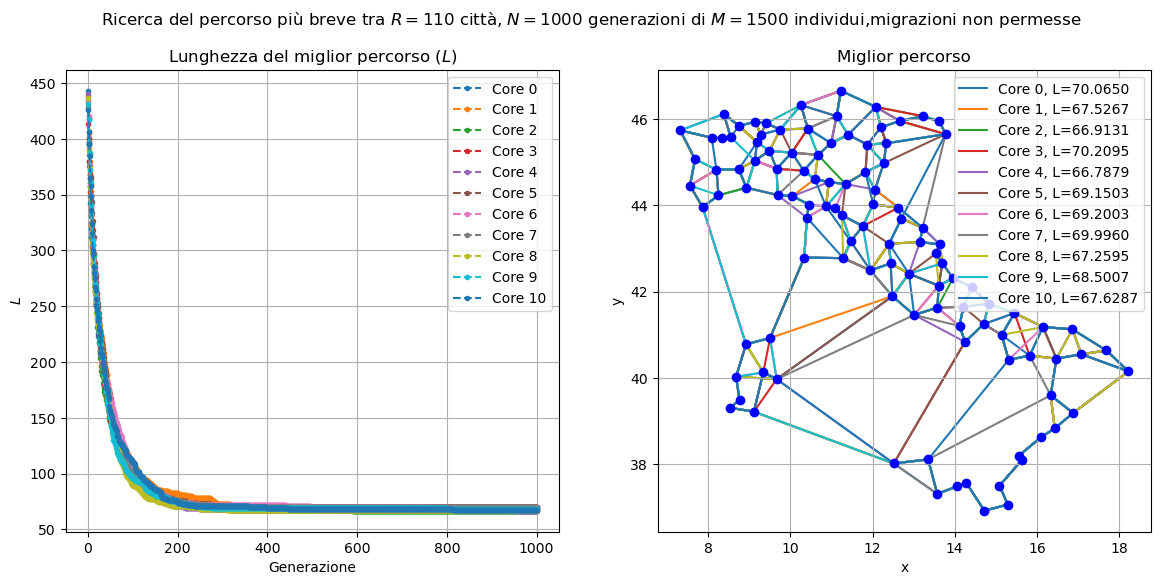

In [6]:
fig,axs=plt.subplots(1,2,figsize=[14,6])
axs[1].scatter(cities[:,0],cities[:,1],color="blue",zorder=2)#città 


for i,best_path in enumerate(NM_best_paths):
    axs[0].plot(NM_gen,NM_best_lenghts[i],"--.",label=f"Core {i}")
    #axs[0].plot(gen,avg_lenghts[i],"--.",label=f"Core {i}, avg")

    index=best_path.astype(int)#ordine in cui le città vengono visitate (percorso migliore)
    axs[1].plot(cities[index,0],cities[index,1],zorder=1,label=f"Core {i}, L={NM_best_lenghts[i][-1]:.4f}") #unisce le città nell'ordine in cui vengono visitate


axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()





axs[1].grid()
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].set_title("Miglior percorso")
axs[1].legend()
fig.suptitle(r"Ricerca del percorso più breve tra $R=110$ città, $N=1000$ generazioni di $M=1500$ individui,migrazioni non permesse");

Con gli stessi parametri del caso precedente, i core arrivano a percorsi diversi, tutti più lunghi di quanto trovato prima. È dunque evidente che la presenza delle migrazioni aiuta la convergenza dell'algoritmo.